In [41]:
import pandas as pd
import numpy as np

In [2]:
data = {
    '과일': ['사과','바나나','딸기','포도','멜론'],
    '가격': [1500,800,3000,2500,5000],
    '재고':[10,20,5,0,3]
}

df = pd.DataFrame(data)
df

,과일,가격,재고
0,사과,1500,10
1,바나나,800,20
2,딸기,3000,5
3,포도,2500,0
4,멜론,5000,3


In [3]:
#특정 조건 필터링 (가격이 2000원 이상인 과일만)
fruits_2000 = df[df['가격']>2000]
fruits_2000

,과일,가격,재고
2,딸기,3000,5
3,포도,2500,0
4,멜론,5000,3


In [4]:
#새로운 열 추가 (총액= 가격*재고)
df['총액'] = df['가격']*df['재고']
df

,과일,가격,재고,총액
0,사과,1500,10,15000
1,바나나,800,20,16000
2,딸기,3000,5,15000
3,포도,2500,0,0
4,멜론,5000,3,15000


In [8]:
#재고가 하나도 없는(0개) 과일의 이름만 출력
df[df['재고']==0]['과일']

3    포도
Name: 과일, dtype: object

In [6]:
#'멜론'의 가격을 4500원으로 수정 (힌트: .loc를 사용하거나 인덱스를 활용)

df.loc[df['과일']=='멜론', '가격'] = 4500
df

,과일,가격,재고,총액
0,사과,1500,10,15000
1,바나나,800,20,16000
2,딸기,3000,5,15000
3,포도,2500,0,0
4,멜론,4500,3,15000


In [19]:
#'오렌지'(가격:1200원, 재고:15) 데이터를 기존 데이터프레임에 추가
# df.loc[len(df['과일'])] = '오렌지',1200,15,0
mango_df = pd.DataFrame([{'과일':'망고', '가격':3000, '재고':10}])
pd.concat([df, mango_df], ignore_index=True)

,과일,가격,재고,총액
0,사과,1500,10,15000.0
1,바나나,800,20,16000.0
2,딸기,3000,5,15000.0
3,포도,2500,0,0.0
4,멜론,4500,3,15000.0
5,오렌지,1200,15,0.0
6,망고,3000,10,NaN


In [21]:
#'종류' 컬럼과 데이터 추가하기
df['종류'] = ['핵과류','인과류','베리류','포도류','박과류','감귤류']
df

,과일,가격,재고,총액,종류
0,사과,1500,10,15000,핵과류
1,바나나,800,20,16000,인과류
2,딸기,3000,5,15000,베리류
3,포도,2500,0,0,포도류
4,멜론,4500,3,15000,박과류
5,오렌지,1200,15,0,감귤류


In [27]:
#모든 과일의 '총액' 합계(전체 재고 자산) 구하기
df['총액'] = df['가격']*df['재고']
df['총액'].sum()

np.int64(77500)

In [30]:
#'가격'이 가장 비싼 순서대로 데이터를 정렬
df.sort_values(by='가격', ascending=True)

,과일,가격,재고,총액,종류
1,바나나,800,20,16000,인과류
5,오렌지,1200,15,18000,감귤류
0,사과,1500,10,15000,핵과류
3,포도,2500,0,0,포도류
2,딸기,3000,5,15000,베리류
4,멜론,4500,3,13500,박과류


In [33]:
data2 = {
    '품목': ['사과', '배', '딸기', '블루베리', '바나나', '망고', '우유', '치즈'],
    '종류': ['과일', '과일', '베리', '베리', '과일', '과일', '유제품', '유제품'],
    '가격': [1500, 2000, 3000, 3500, 1000, 2500, 2200, 4500],
    '재고': [10, 5, 8, 12, 20, 7, 15, 3]
}
df2 = pd.DataFrame(data2)
df2

,품목,종류,가격,재고
0,사과,과일,1500,10
1,배,과일,2000,5
2,딸기,베리,3000,8
3,블루베리,베리,3500,12
4,바나나,과일,1000,20
5,망고,과일,2500,7
6,우유,유제품,2200,15
7,치즈,유제품,4500,3


In [35]:
#과일, 베리, 유제품별로 '가격'의 평균 구하기
df2.groupby('종류')['가격'].mean()

종류
과일     1750.0
베리     3250.0
유제품    3350.0
Name: 가격, dtype: float64

In [36]:
#종류별로 '재고'가 총 몇 개 있는지 합계 구하기
df2.groupby('종류')['재고'].sum()

종류
과일     42
베리     20
유제품    18
Name: 재고, dtype: int64

In [37]:
#종류별로 가장 비싼 가격을 구한 뒤, 그 결과를 '가격이 높은 순서(내림차순)'으로 정렬
df2.groupby('종류')['가격'].max().sort_values(ascending=False)

종류
유제품    4500
베리     3500
과일     2500
Name: 가격, dtype: int64

In [42]:
data3 = {
    '이름': ['철수', '영희', '민수', '수지'],
    '수학': [90, 80, np.nan, 70], # 민수의 수학 점수가 비어있음
    '영어': [85, np.nan, 95, 100], #영희으 영어 점수가 비어있음
    '지역': ['서울', '부산', '서울', '제주']
}

df_exam = pd.DataFrame(data3)
df_exam

,이름,수학,영어,지역
0,철수,90.0,85.0,서울
1,영희,80.0,NaN,부산
2,민수,NaN,95.0,서울
3,수지,70.0,100.0,제주


In [44]:
# 각 컬럼별로 비어있는 값(NaN)이 몇 개씩 있는지 확인
df_exam.isnull().sum()

이름    0
수학    1
영어    1
지역    0
dtype: int64

In [52]:
# 수학 점수의 비어있는 부분(NaN)을 나머지 학생들의 수학 점수 평균으로 채우기
df_exam['수학'] = df_exam['수학'].fillna(df_exam['수학'].mean())
df_exam

,이름,수학,영어,지역
0,철수,90.0,85.0,서울
1,영희,80.0,NaN,부산
2,민수,80.0,95.0,서울
3,수지,70.0,100.0,제주


In [53]:
# 영어 점수가 비어있는 학생(행)을 데이터프레임에서 제거한 새로운 결과물
df_exam.dropna()

,이름,수학,영어,지역
0,철수,90.0,85.0,서울
2,민수,80.0,95.0,서울
3,수지,70.0,100.0,제주


In [57]:
# 매출 데이터 (어떤 물건이 몇 개 팔렸나?)
sales_data = {
    '상품명': ['삼각김밥', '도시락', '컵라면', '콜라', '삼각김밥', '컵라면'],
    '판매수량': [10, 5, 8, 15, 12, 7],
    '판매단가': [1200, 4500, 1500, 1800, 1200, 1500]
}

# 카테고리 정보 (상품이 어떤 종류인가?)
category_data = {
    '상품명': ['삼각김밥', '도시락', '컵라면', '콜라', '생수'],
    '카테고리': ['식사류', '식사류', '식사류', '음료', '음료']
}

sales_df = pd.DataFrame(sales_data)
cat_df = pd.DataFrame(category_data)
sales_df
cat_df

,상품명,카테고리
0,삼각김밥,식사류
1,도시락,식사류
2,컵라면,식사류
3,콜라,음료
4,생수,음료


In [59]:
# pd.merge()를 사용해 sales_df에 cat_df의 '카테고리' 정보를 붙여보기
df3 = pd.merge(sales_df, cat_df)
df3

,상품명,판매수량,판매단가,카테고리
0,삼각김밥,10,1200,식사류
1,도시락,5,4500,식사류
2,컵라면,8,1500,식사류
3,콜라,15,1800,음료
4,삼각김밥,12,1200,식사류
5,컵라면,7,1500,식사류


In [62]:
#각 행별로 매출액 열 만들기 (판매수량*판매단가)
df3['매출액'] = df3['판매수량']*df3['판매단가']
df3

,상품명,판매수량,판매단가,카테고리,매출액
0,삼각김밥,10,1200,식사류,12000
1,도시락,5,4500,식사류,22500
2,컵라면,8,1500,식사류,12000
3,콜라,15,1800,음료,27000
4,삼각김밥,12,1200,식사류,14400
5,컵라면,7,1500,식사류,10500


In [65]:
#'카테고리'별로 전체 '매출액'의 합계를 구하기 / 가장 돈을 많이 벌어다 준 카테고리
category_sales = df3.groupby('카테고리')['매출액'].sum().sort_values(ascending=True)
category_sales

카테고리
음료     27000
식사류    71400
Name: 매출액, dtype: int64

In [64]:
import matplotlib.pyplot as plt

#폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
#마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

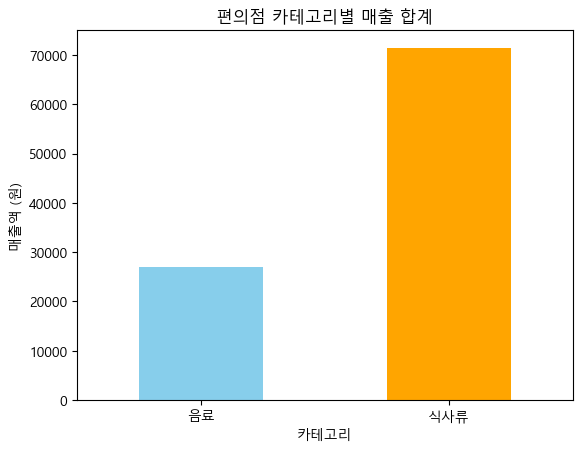

In [66]:
result = pd.Series(category_sales)

# 막대 그래프 그리기
result.plot(kind='bar', color=['skyblue', 'orange'], rot=0)

# 꾸미기
plt.title('편의점 카테고리별 매출 합계')
plt.xlabel('카테고리')
plt.ylabel('매출액 (원)')

plt.show()

In [70]:
data = {
    '요일': ['월', '화', '수', '목', '금', '토', '일'],
    '방문자수': [120, 150, 130, 200, 300, 500, 450]
}
df_visit = pd.DataFrame(data)
df_visit

,요일,방문자수
0,월,120
1,화,150
2,수,130
3,목,200
4,금,300
5,토,500
6,일,450


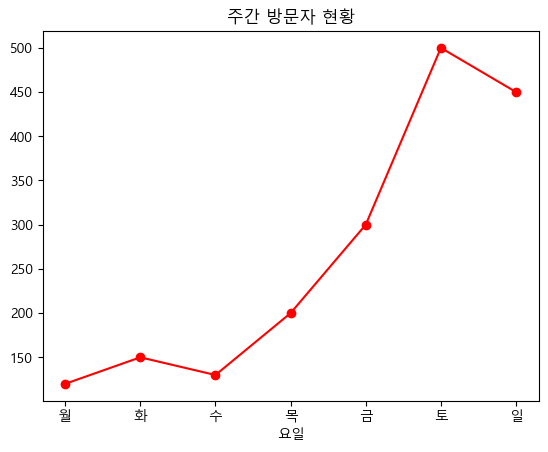

In [80]:
# 선 그래프 : 요일별 방문자수의 변화를 선 그래프로 그리기
df_visit.set_index('요일')['방문자수'].plot(kind='line', color='red', marker='o')

plt.title('주간 방문자 현황')
plt.show()

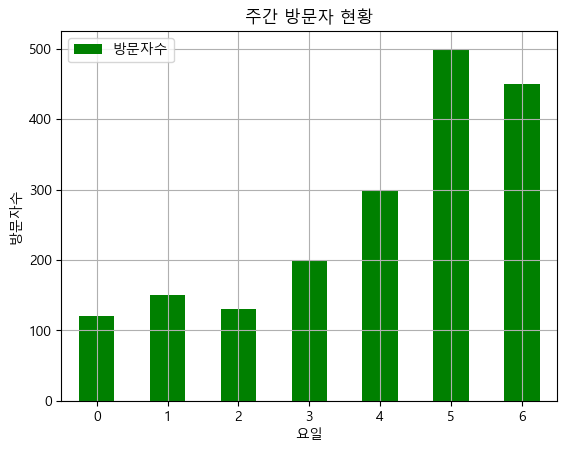

In [78]:
# 막대 그래프 : 방문자수가 가장 많은 요일을 강조하기 위해 막대 그래프로 바꿔보기 색상은 'green'
df_visit.plot(kind='bar', color='green', rot=0, grid=True)

plt.title('주간 방문자 현황')
plt.xlabel('요일')
plt.ylabel('방문자수')

plt.show()

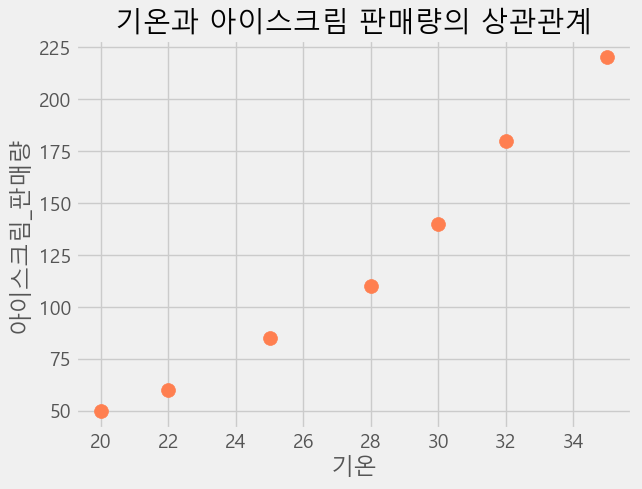

In [84]:
# 상관관계 분석용 데이터
df_store = pd.DataFrame({
    '기온': [20, 22, 25, 28, 30, 32, 35],
    '아이스크림_판매량': [50, 60, 85, 110, 140, 180, 220]
})

# 산점도 그리기 (x축과 y축을 지정해야 합니다)
df_store.plot(kind='scatter', x='기온', y='아이스크림_판매량', s=100, color='coral')
plt.title('기온과 아이스크림 판매량의 상관관계')
plt.show()

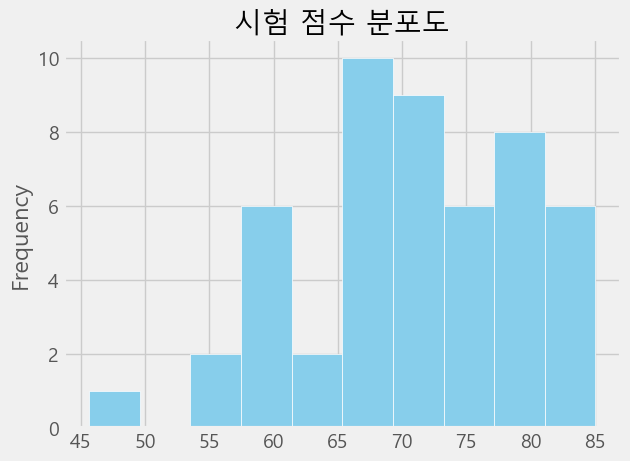

In [85]:
scores = np.random.normal(70, 10, 50) # 평균 70, 표준편차 10인 점수 50개 생성
df_scores = pd.DataFrame(scores, columns=['점수'])

# 히스토그램 그리기
# bins=10은 데이터를 10개의 구간으로 나누겠다는 뜻입니다.
df_scores['점수'].plot(kind='hist', bins=10, color='skyblue', edgecolor='white')
plt.title('시험 점수 분포도')
plt.show()

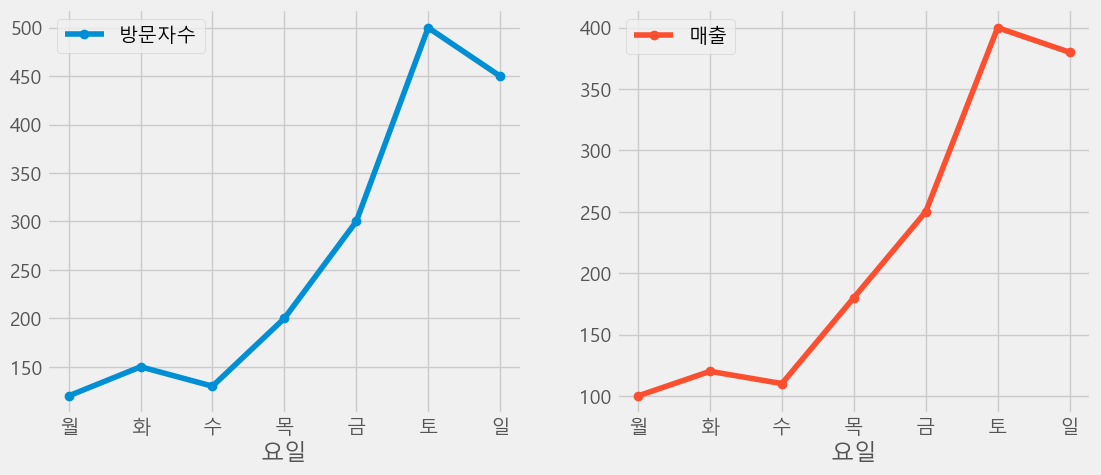

In [86]:
df_visit = pd.DataFrame({
    '요일': ['월', '화', '수', '목', '금', '토', '일'],
    '방문자수': [120, 150, 130, 200, 300, 500, 450],
    '매출': [100, 120, 110, 180, 250, 400, 380]
}).set_index('요일')

# layout=(행, 열) 설정으로 배치 조절 가능
df_visit.plot(subplots=True, layout=(1, 2), figsize=(12, 5), kind='line', marker='o')
plt.show()

In [88]:
data = {
    '이름': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    '공부시간': [2, 3, 5, 1, 8, 6, 4],
    '성적': [50, 65, 80, 40, 95, 85, 70]
}
df_study = pd.DataFrame(data)
df_study

,이름,공부시간,성적
0,A,2,50
1,B,3,65
2,C,5,80
3,D,1,40
4,E,8,95
5,F,6,85
6,G,4,70


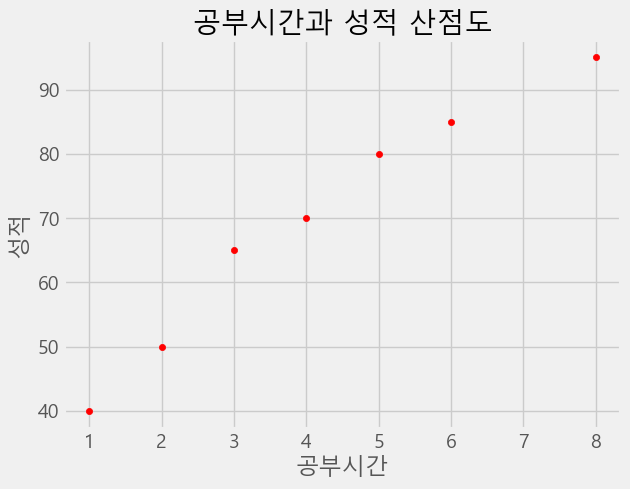

In [93]:
# '공부시간'과 '성적' 사이의 관계를 보여주는 '산점도(Scatter)'를 그려보기, 점의 색상은 'red'
df_study.plot(kind='scatter', x='공부시간', y='성적', color='red', marker='o')

plt.title('공부시간과 성적 산점도')
plt.show()

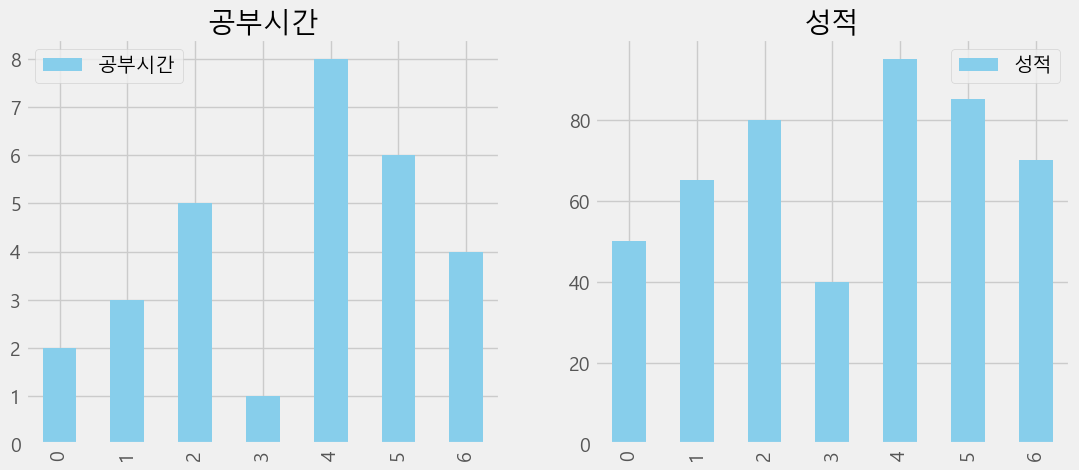

In [97]:
#subplots=True를 사용해 '공부시간'과 '성적' 각각의 **막대 그래프(Bar)**를 한 화면에 나란히 그려보기
df_study.plot(subplots=True, kind='bar', layout=(1, 2), figsize=(12, 5), color='skyblue')
plt.show()

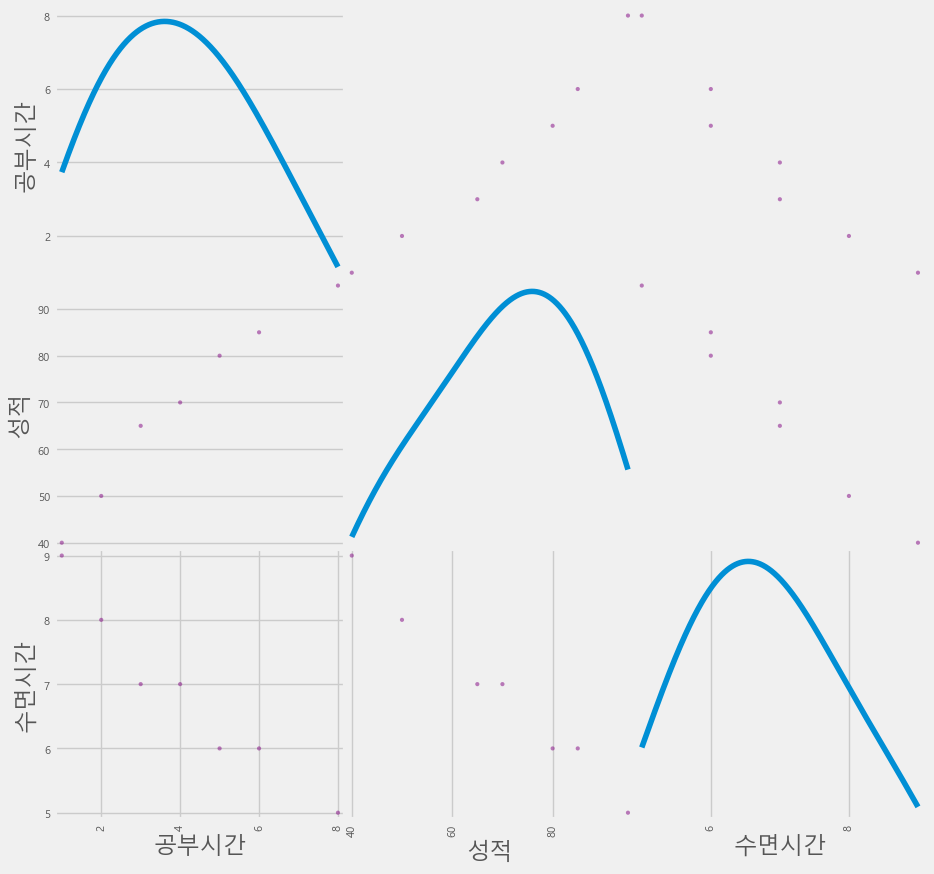

In [99]:
from pandas.plotting import scatter_matrix
# 여러 변수가 있는 데이터
df_multi = pd.DataFrame({
    '공부시간': [2, 3, 5, 1, 8, 6, 4],
    '성적': [50, 65, 80, 40, 95, 85, 70],
    '수면시간': [8, 7, 6, 9, 5, 6, 7]
})

scatter_matrix(df_multi, figsize=(10, 10), diagonal='kde', color='purple')
plt.show()

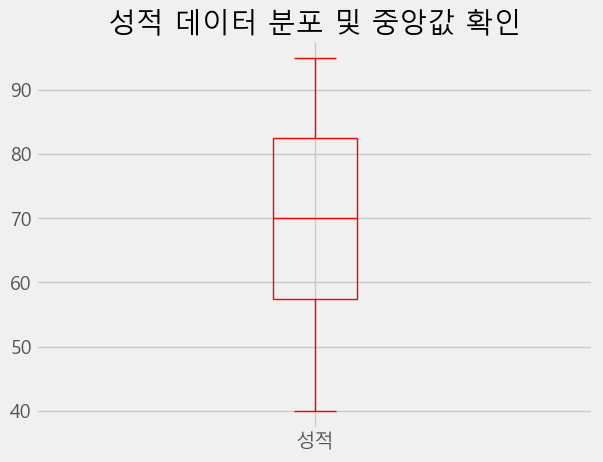

In [100]:
# 성적 분포 확인
df_multi['성적'].plot(kind='box', color='red')
plt.title('성적 데이터 분포 및 중앙값 확인')
plt.show()

In [102]:
health_data = {
    '운동시간(분)': [30, 60, 90, 20, 120, 40, 80, 100],
    '체지방률(%)': [25, 20, 15, 28, 10, 22, 18, 12]
}
df_health = pd.DataFrame(health_data)
df_health

,운동시간(분),체지방률(%)
0,30,25
1,60,20
2,90,15
3,20,28
4,120,10
5,40,22
6,80,18
7,100,12


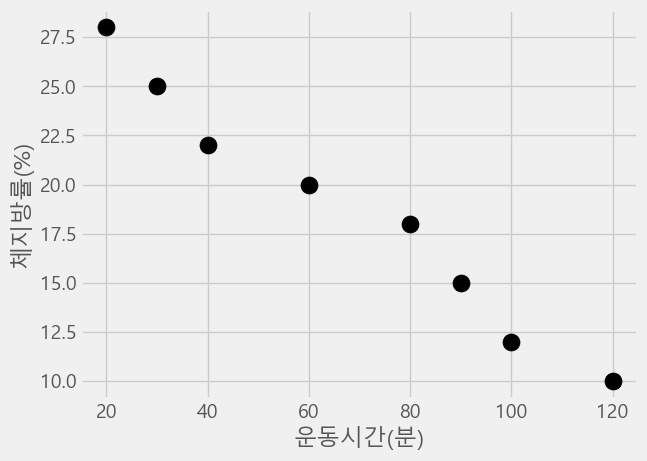

In [106]:
# '운동시간'과 '체지방률'의 관계룰 '산점도'로 그리고, 점의 크기를 s=150으로 키우기
df_health.plot(kind='scatter', color='black', x='운동시간(분)', y='체지방률(%)', s=150, marker='o')
plt.show()